# GPT-2 forward pass: интерактивный разбор

Ноутбук умеет:

1. **Грубый запуск** всех или некоторых этапов модели целиком (эмбеддинги → блоки → lm_head → декодирование токенов) — `run_pipeline(...)`.
2. **Фокус на конкретном этапе** с детализацией поэтапно, как и раньше (ln_1 → qkv → heads → scores → mask → softmax → attn_v → attn_proj → resid1 → ln_2 → mlp_fc → mlp_act → mlp_proj → resid2), при этом выбранный блок может быть не первым — состояние модели сохраняется в `WalkerState`, пересчитывать всё с нуля не нужно.
3. **Модульная визуализация/сохранение** — каждый «рекордер» (heatmap внимания, heatmap MLP, ближайшие токены, норма/cos-similarity, сверка с эталоном, сохранение тензоров на диск) включается/выключается независимо.
4. **Батч-обработка** — прогон на N промптах с выгрузкой выбранных тензоров (например, attention конкретного слоя) в файл.

Вся «движковая» логика вынесена в соседний модуль **`gpt2_walker.py`** — положите его в ту же папку, что и этот ноутбук. Сам ноутбук — это интерактивная обвязка над ним: меняете параметры в ячейках и смотрите на результат, не трогая код движка.

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F

#from hui_extended import logits_manual

from gpt2_walker import (
    GPT2Walker, WalkerState, BLOCK_STAGES, build_default_walker,
    run_pipeline, run_batch,
    Recorder, AttentionHeatmapRecorder, HiddenHeatmapRecorder,
    NearestTokensRecorder, ResidualDeltaRecorder, ReferenceDiffRecorder, TensorSaver,
)
from hui_gpt2_1 import sample_num

MODEL_NAME = "./weiser/101M-0.4"

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config._attn_implementation = "eager"
model.eval()
print(model)

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 6629.62it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 704)
    (wpe): Embedding(1024, 704)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-10): 11 x GPT2Block(
        (ln_1): LayerNorm((704,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2112, nx=704)
          (c_proj): Conv1D(nf=704, nx=704)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((704,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=2816, nx=704)
          (c_proj): Conv1D(nf=704, nx=2816)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((704,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=704, out_features=50257, bias=False)
)


In [4]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

In [47]:
math_expressions = [
    "Ten plus five equals to ",
    "Eight minus three equals to ",
    "Six times two equals to ",
    "Nine plus seven equals to ",
    "Four times one equals to ",
    "Twelve minus six equals to ",
    "Three times five equals to ",
    "Seven plus zero equals to ",
    "Two times nine equals to ",
    "Eleven minus four equals to "
]

sentences = [
    "Cats love fish because of ",
    "Dogs chase balls because of ",
    "Birds build nests because of ",
    "Bears eat honey because of ",
    "Cows chew grass because of ",
    "Frogs catch flies because of ",
    "Bees make honey because of ",
    "Monkeys love bananas because of ",
    "Spiders spin webs because of ",
    "Horses eat hay because of "
]

sample_num = 3
system_promptr = "You are a calculator. You only output the numeric result of the given arithmetic expression. Never explain, never add words or symbols other than the number. Output exactly one line containing only the answer.\
\
Expression: 2 + 2\
Answer: 4\
\
Expression: 9 - 4\
Answer: 5\
\
Expression: 7 * 6\
Answer: 42\
\
Expression: 20 / 4\
Answer: 5\
\
Expression:" + math_expressions[sample_num] + "\
Answer:"


In [48]:
prompt = "two plus two equals to " # math_expressions[sample_num]
sample_label = "other_" + str(sample_num)
SAMPLES_DIR = "./samples/"

## Быстрая проверка токенизации (опционально)

`walker.start()` ниже делает то же самое сам, эта ячейка — просто чтобы посмотреть на токены и id глазами перед разбором.

In [44]:
tokens = tokenizer.tokenize(prompt)
print(tokens)

ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
print(ids)

['two', 'Ġplus', 'Ġtwo', 'Ġequals', 'Ġto', 'Ġ']
tensor([[11545,  5556,   734, 21767,   284,   220]])


## Инициализация walker'а и набора рекордеров (пункт 3 — модульность)

`build_default_walker` собирает тот же набор визуализаторов/проверок, что был в исходном ноутбуке, но каждый из них — независимый объект-рекордер, который можно включать и выключать через `walker.set_enabled(name, bool)`:

| name | что делает | стадии-триггеры |
|---|---|---|
| `attention_heatmap` | heatmap внимания по головам | `softmax` |
| `hidden_heatmap` | heatmap MLP-активаций (до/после нелинейности, после проекции) | `mlp_fc`, `mlp_act`, `mlp_proj` |
| `nearest_tokens` | ближайшие токены словаря по cos-similarity | `resid1`, `resid2` |
| `residual_delta` | ||attn_out||/||x|| и cos(x, attn_out) | `resid1`, `resid2` |
| `reference_diff` | max abs diff vs эталонный прогон HF-модели | `embed`, `softmax`, `resid2`, `lm_head` |

Полный список стадий блока — в `BLOCK_STAGES`, кэш каждой стадии (какие тензоры в `state.cache` появляются) — в docstring'ах классов-рекордеров в `gpt2_walker.py`.

In [45]:
walker = build_default_walker(
    model, tokenizer,
    with_heatmaps=True,          # attention_heatmap + hidden_heatmap
    with_text_diagnostics=True,  # nearest_tokens + residual_delta
    with_reference_check=True,   # reference_diff
)
print(walker)
print("Стадии внутри блока:", BLOCK_STAGES)

GPT2Walker(layers=11, heads=11, embed_dim=704) recorders=[attention_heatmap(on), hidden_heatmap(on), nearest_tokens(on), residual_delta(on), reference_diff(on)]
Стадии внутри блока: ('ln_1', 'qkv', 'heads', 'scores', 'mask', 'softmax', 'attn_v', 'attn_proj', 'resid1', 'ln_2', 'mlp_fc', 'mlp_act', 'mlp_proj', 'resid2')


## 1) Грубый запуск всех или некоторых этапов модели

`run_pipeline(walker, prompt, ...)` прогоняет верхнеуровневые этапы — эмбеддинги → N блоков → lm_head → декодирование — каждый из которых можно включить/выключить:

* `num_blocks` — сколько блоков прогнать (`0` = только эмбеддинги, `None` = все блоки модели)
* `detail` — блоки считать быстро (`False`, родной forward) или по шагам (`True`, тогда сработают все рекордеры на каждой под-стадии)
* `do_lm_head` / `do_decode` — нужны ли финальные logits / топ-k предсказание

Это самый верхний уровень — для тонкой пошаговой работы с ОДНИМ конкретным блоком см. раздел 2 ниже.

In [46]:
# Полный прогон: все блоки быстро (без детализации), затем lm_head и топ-k предсказание
state_full = run_pipeline(walker, prompt, num_blocks=None, detail=False,
                           do_lm_head=True, do_decode=True, top_k=15)

  max abs diff vs hidden_states[0] (эмбеддинги) (эталон): 0.000e+00

-- ближайшие токены словаря, layer=0, stage=resid2 --
  [0] исходный='two': 'Ġprominent'=0.113, 'Ġmen'=0.112, 'Ġmixed'=0.111, 'Ġcaptured'=0.103, 'Ġthousand'=0.099  gap=0.0005
  [1] исходный='Ġplus': 'Ġthree'=0.140, 'Ġtwo'=0.122, 'Ġfour'=0.105, 'Ġthe'=0.105, 'Ġ$'=0.102  gap=0.0181
  [2] исходный='Ġtwo': 'Ġhundred'=0.138, 'Ġthousand'=0.130, 'Ġweek'=0.116, 'Ġdozen'=0.112, 'Ġprominent'=0.112  gap=0.0078
  [3] исходный='Ġequals': 'Ġno'=0.102, 'Ġpaying'=0.091, 'Ġzero'=0.091, 'Ġpair'=0.085, 'Ġset'=0.085  gap=0.0103
  [4] исходный='Ġto': 'Ġgive'=0.140, 'Ġset'=0.135, 'Ġbe'=0.126, 'Ġmake'=0.121, 'Ġsave'=0.113  gap=0.0049
  [5] исходный='Ġ': 'ĠâĢ'=0.126, 'Ġ$'=0.122, 'Ġp'=0.110, 'Ġmar'=0.108, 'ired'=0.107  gap=0.0039
  [residual_delta] пропущен на стадии 'resid2': нет тензора 'resid1' в кэше (вероятно, использован detail=False)
  max abs diff vs hidden_states[1] (выход блока 0) (эталон): 0.000e+00

-- ближайшие токены словаря, la

In [40]:
# Только эмбеддинги -- быстрая проверка без блоков/lm_head/декодирования
walker.set_enabled("reference_diff", True)   # для остальных секций ниже можно выключать по своему усмотрению
state_embed_only = run_pipeline(walker, prompt, num_blocks=0,
                                 do_lm_head=False, do_decode=False)
print(state_embed_only)

  max abs diff vs hidden_states[0] (эмбеддинги) (эталон): 0.000e+00
WalkerState(prompt='Nine plus seven equals to ', layer_idx=-1, stage='embed', seq_len=6)


In [41]:
# Первые 2 блока, без lm_head и без декодирования -- удобно, когда интересен только
# промежуточный residual stream, а не финальное предсказание
state_partial = run_pipeline(walker, prompt, num_blocks=2, detail=False,
                              do_lm_head=False, do_decode=False)
print(state_partial)
print("x shape после 2 блоков:", state_partial.x.shape)

  max abs diff vs hidden_states[0] (эмбеддинги) (эталон): 0.000e+00

-- ближайшие токены словаря, layer=0, stage=resid2 --
  [0] исходный='Nine': 'Ġlatest'=0.101, 'Ġoffice'=0.101, 'Ġprominent'=0.101, 'Ġmixed'=0.100, 'Ġthousand'=0.096  gap=0.0005
  [1] исходный='Ġplus': 'Ġthree'=0.152, 'Ġtwo'=0.126, 'Ġfour'=0.114, 'Ġfive'=0.113, 'Ġthe'=0.111  gap=0.0264
  [2] исходный='Ġseven': 'Ġdays'=0.138, 'Ġweeks'=0.127, 'Ġmonths'=0.123, 'Ġyears'=0.121, 'Ġthousand'=0.113  gap=0.0107
  [3] исходный='Ġequals': 'Ġno'=0.111, 'Ġpaying'=0.104, 'Ġthree'=0.093, 'Ġzero'=0.093, 'Ġover'=0.090  gap=0.0078
  [4] исходный='Ġto': 'Ġgive'=0.143, 'Ġset'=0.133, 'Ġbe'=0.126, 'Ġmake'=0.122, 'Ġsave'=0.113  gap=0.0098
  [5] исходный='Ġ': 'ĠâĢ'=0.130, 'Ġ$'=0.125, 'Ġp'=0.115, 'ĠÂ£'=0.113, 'Ġmar'=0.108  gap=0.0054
  [residual_delta] пропущен на стадии 'resid2': нет тензора 'resid1' в кэше (вероятно, использован detail=False)
  max abs diff vs hidden_states[1] (выход блока 0) (эталон): 0.000e+00

-- ближайшие токены словаря,

## 2) Фокус на конкретном этапе: пошаговая детализация с сохранением состояния

Выбираем **любой** блок модели (необязательно нулевой) через `TARGET_LAYER`. `walker.fast_forward(state, TARGET_LAYER)` быстро (без детализации, одним `forward` на блок) досчитывает всё, что было **до** этого блока, и останавливается ровно на границе перед ним — сам `TARGET_LAYER` не трогает.

Дальше идём по нему вручную, `walker.step(state)` за раз — ровно та же детализация, что была в исходном ноутбуке (ln_1 → qkv → heads → scores → mask → softmax → attn_v → attn_proj → resid1 → ln_2 → mlp_fc → mlp_act → mlp_proj → resid2), только теперь применимая к любому блоку, а не только к блоку 0.

In [12]:
TARGET_LAYER = min(3, len(model.transformer.h) - 1)  # поменяйте на любой интересующий блок

state = walker.start(prompt, with_reference=True)
walker.fast_forward(state, TARGET_LAYER)
print(f"Состояние готово к детальному разбору блока {TARGET_LAYER}: {state}")

  max abs diff vs hidden_states[0] (эмбеддинги) (эталон): 0.000e+00

-- ближайшие токены словаря, layer=0, stage=resid2 --
  [0] исходный='B': 'ĠâĢ'=0.123, 'ĠPr'=0.110, 'ĠP'=0.104, 'ĠTri'=0.103, 'Ġmatch'=0.103  gap=0.0122
  [1] исходный='ears': 'ail'=0.135, 'y'=0.129, 'ection'=0.121, 'Ġtestimony'=0.118, 'Ġhot'=0.116  gap=0.0059
  [2] исходный='Ġeat': 'Ġno'=0.104, 'Ġfriendly'=0.102, 'Ġwell'=0.102, 'Ġ$'=0.100, 'Ġmixed'=0.100  gap=0.0015
  [3] исходный='Ġhoney': 'moon'=0.152, 'comb'=0.142, 'com'=0.141, 'es'=0.118, 'ĠSw'=0.109  gap=0.0107
  [4] исходный='Ġbecause': 'Ġevery'=0.117, 'Ġthere'=0.102, 'Ġit'=0.102, 'Ġhigh'=0.101, 'Ġno'=0.098  gap=0.0146
  [5] исходный='Ġof': 'Ġthe'=0.129, 'Ġmy'=0.116, 'ĠâĢ'=0.115, 'Ġmine'=0.111, 'Ġa'=0.108  gap=0.0132
  [6] исходный='Ġ': 'Ġmar'=0.133, 'ĠâĢ'=0.131, 'ĠSw'=0.122, 'Ġdev'=0.116, 'Ġp'=0.114  gap=0.0020
  [residual_delta] пропущен на стадии 'resid2': нет тензора 'resid1' в кэше (вероятно, использован detail=False)
  max abs diff vs hidden_states[1] (вы

In [13]:
# --- Шаг 1. LayerNorm перед attention (GPT-2: обычный LayerNorm, не RMSNorm) ---
walker.step(state)
print("stage:", state.stage, "| x_norm shape:", state.cache["ln1_out"].shape)

stage: ln_1 | x_norm shape: torch.Size([1, 7, 704])


In [14]:
# --- Шаг 2. Q, K, V одним проходом через c_attn, затем разрезаем ---
# В Llama это три разных Linear (q_proj/k_proj/v_proj).
# В GPT-2 это ОДИН Conv1D, который сразу выдаёт [Q | K | V] склеенными по последней размерности.
walker.step(state)
print("stage:", state.stage)
print("q:", state.cache["q"].shape, "k:", state.cache["k"].shape, "v:", state.cache["v"].shape)

stage: qkv
q: torch.Size([1, 7, 704]) k: torch.Size([1, 7, 704]) v: torch.Size([1, 7, 704])


In [15]:
# --- Шаг 3. Reshape на головы ---
# В GPT-2 НЕТ шага "применить RoPE" -- позиция уже учтена через wpe на этапе эмбеддингов.
walker.step(state)
print("stage:", state.stage, "| q_h shape:", state.cache["q_h"].shape)

stage: heads | q_h shape: torch.Size([1, 11, 7, 64])


In [16]:
# --- Шаг 4. Scores = Q*K^T / sqrt(head_dim) ---
walker.step(state)
print("stage:", state.stage, "| scores shape:", state.cache["scores"].shape)

stage: scores | scores shape: torch.Size([1, 11, 7, 7])


In [17]:
# --- Шаг 5. Causal mask ---
walker.step(state)
print("stage:", state.stage, "| scores_masked shape:", state.cache["scores_masked"].shape)

stage: mask | scores_masked shape: torch.Size([1, 11, 7, 7])


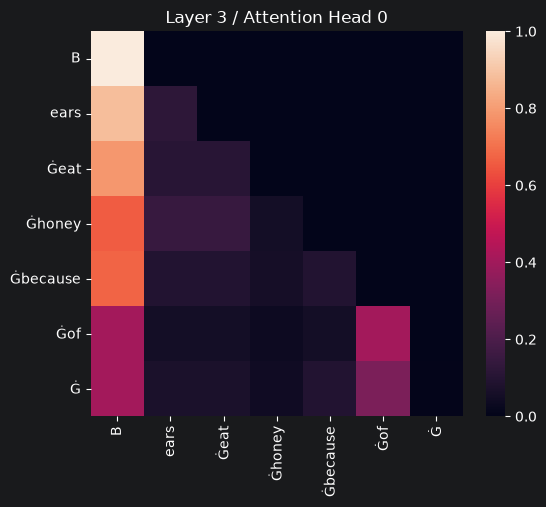

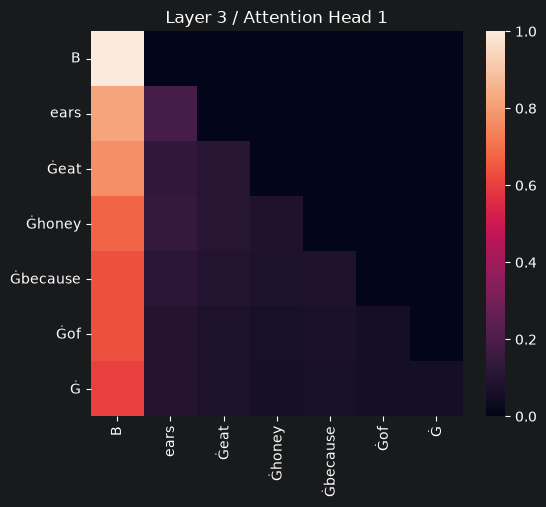

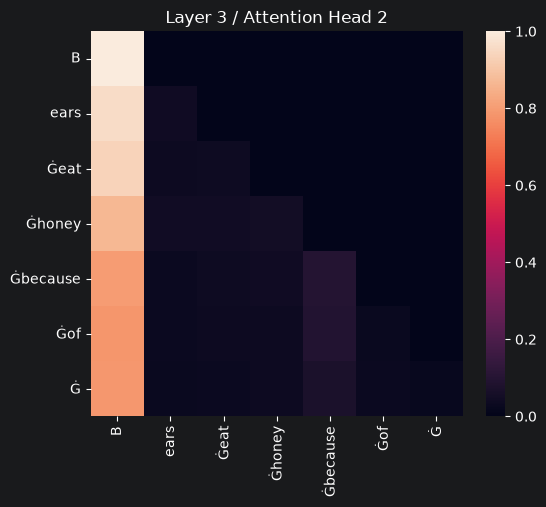

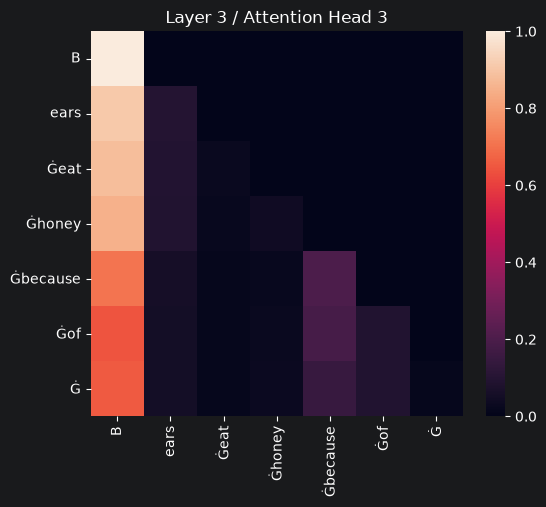

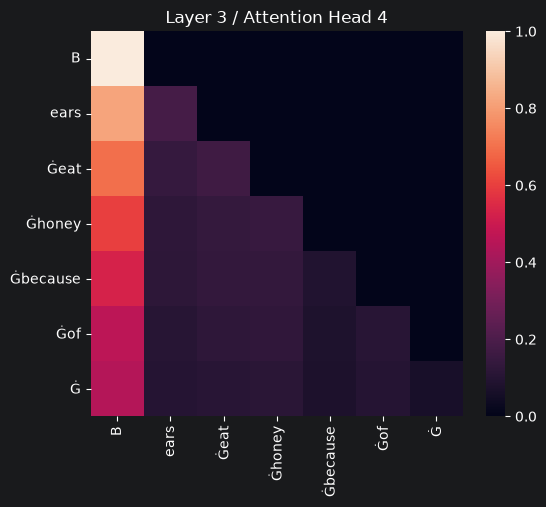

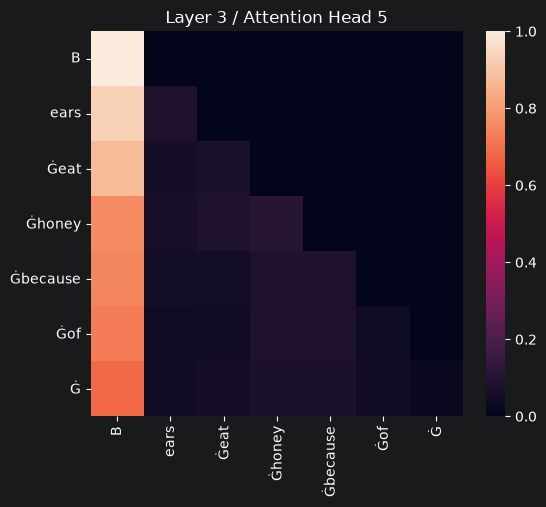

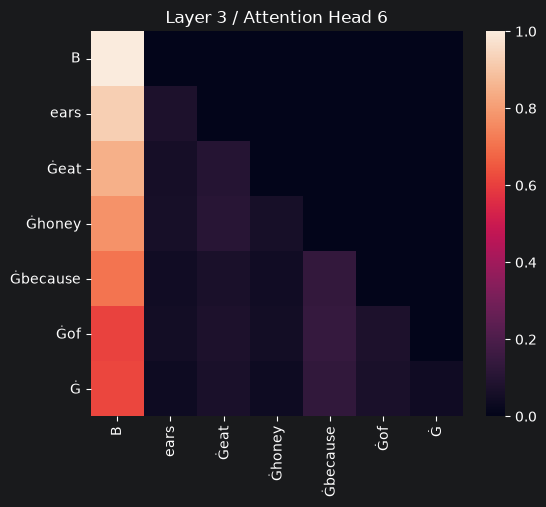

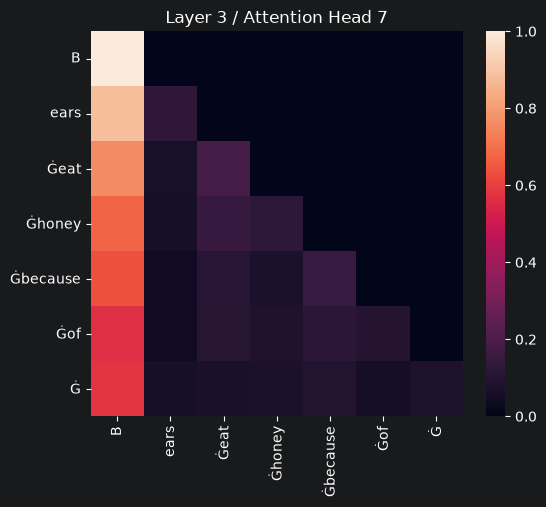

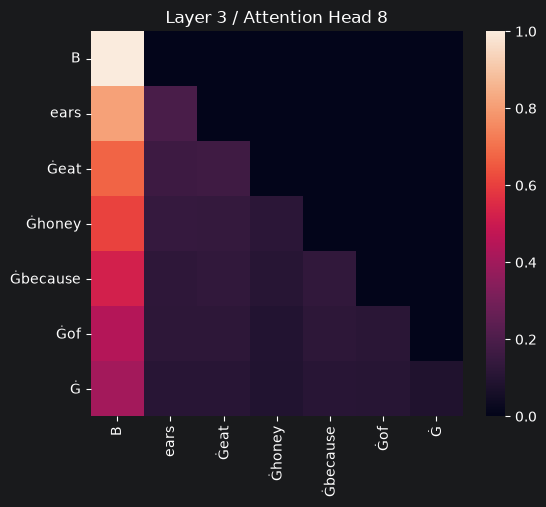

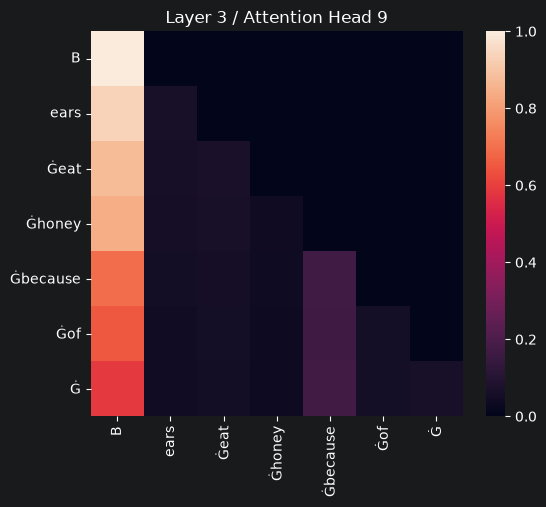

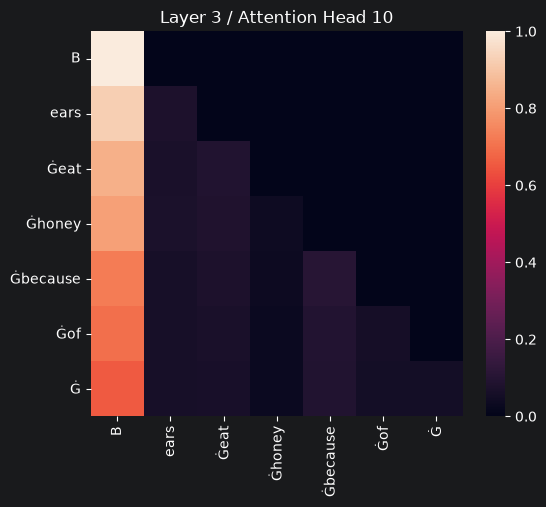

  max abs diff vs attentions[3] (эталон): 0.000e+00
stage: softmax


In [18]:
# --- Шаг 6. Softmax -> веса внимания ---
# Сработают recorder'ы: attention_heatmap (картинки по головам) и reference_diff (сверка с outputs.attentions)
walker.step(state)
print("stage:", state.stage)

In [19]:
# --- Шаг 7. attn_weights @ V ---
walker.step(state)
print("stage:", state.stage, "| attn_out_heads shape:", state.cache["attn_out_heads"].shape)

stage: attn_v | attn_out_heads shape: torch.Size([1, 11, 7, 64])


In [20]:
# --- Шаг 8. Склеиваем головы и c_proj ---
walker.step(state)
print("stage:", state.stage, "| attn_out shape:", state.cache["attn_out"].shape)

stage: attn_proj | attn_out shape: torch.Size([1, 7, 704])


In [21]:
# --- Шаг 9. Первый residual connection ---
# Сработают recorder'ы: nearest_tokens (ближайшие токены словаря) и residual_delta (норма/cos)
walker.step(state)
print("stage:", state.stage, "| resid1 shape:", state.cache["resid1"].shape)


-- ближайшие токены словаря, layer=3, stage=resid1 --
  [0] исходный='B': 'Ġcontracted'=0.115, 'Ġprime'=0.112, 'ĠStar'=0.109, 'Ġmatching'=0.105, 'Ġsupportive'=0.095  gap=0.0029
  [1] исходный='ears': 'Ġhot'=0.115, 'Ġpro'=0.106, 'Ġtight'=0.104, 'man'=0.104, 'ail'=0.104  gap=0.0088
  [2] исходный='Ġeat': 'Ġmixed'=0.110, 'Ġprime'=0.106, 'Ġstocking'=0.101, 'Ġgreat'=0.101, 'Ġproducing'=0.101  gap=0.0039
  [3] исходный='Ġhoney': 'moon'=0.144, 'com'=0.120, 'Ġhome'=0.113, 'comb'=0.103, 'Ġsw'=0.103  gap=0.0234
  [4] исходный='Ġbecause': 'Ġevery'=0.117, 'Ġmajor'=0.115, 'Ġhigh'=0.108, 'Ġbuying'=0.105, 'Ġthey'=0.103  gap=0.0020
  [5] исходный='Ġof': 'Ġmixed'=0.118, 'ĠâĢ'=0.117, 'Ġcourse'=0.114, 'Ġtheir'=0.114, 'Ġmine'=0.111  gap=0.0010
  [6] исходный='Ġ': 'ĠâĢ'=0.133, 'irc'=0.122, 'Ġmar'=0.117, 'ery'=0.110, 'vern'=0.110  gap=0.0107

-- residual delta, layer=3, stage=resid1 --
  [0]  ||base||=63.500 ||delta||=13.125 ratio=0.207  cos=-0.0476
  [1]  ||base||=28.750 ||delta||=12.062 ratio=0.420  cos=

In [22]:
# --- Шаг 10. LayerNorm перед MLP ---
walker.step(state)
print("stage:", state.stage, "| ln2_out shape:", state.cache["ln2_out"].shape)

stage: ln_2 | ln2_out shape: torch.Size([1, 7, 704])


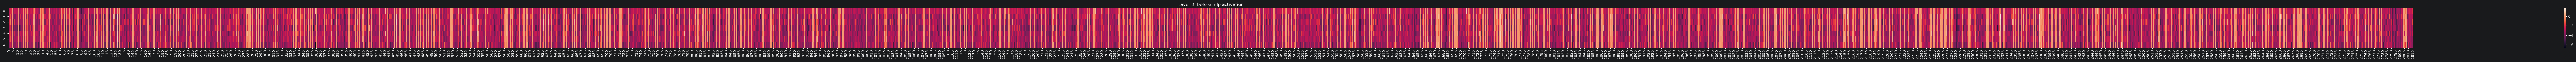

stage: mlp_fc | mlp_pre_act shape: torch.Size([1, 7, 2816])


In [23]:
# --- Шаг 11. MLP: c_fc (embed_dim -> intermediate) ---
# Сработает recorder hidden_heatmap ("before mlp activation")
walker.step(state)
print("stage:", state.stage, "| mlp_pre_act shape:", state.cache["mlp_pre_act"].shape)

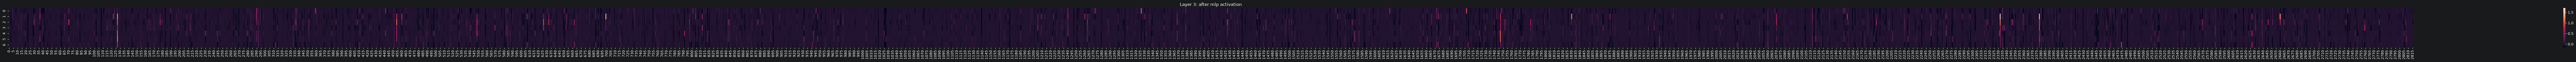

stage: mlp_act | mlp_post_act shape: torch.Size([1, 7, 2816])


In [24]:
# --- Шаг 12. Нелинейность (GELU, см. config.activation_function) ---
# Сработает recorder hidden_heatmap ("after mlp activation")
walker.step(state)
print("stage:", state.stage, "| mlp_post_act shape:", state.cache["mlp_post_act"].shape)

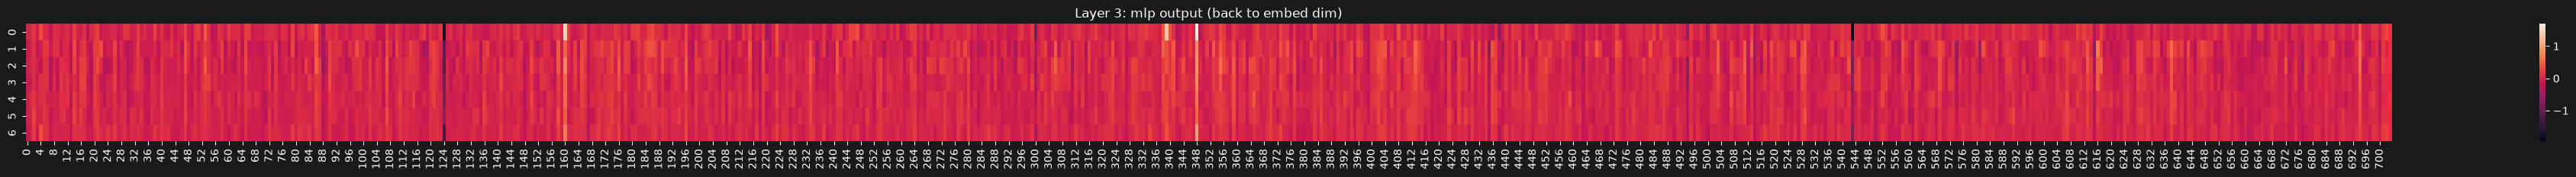

stage: mlp_proj | mlp_out shape: torch.Size([1, 7, 704])


In [25]:
# --- Шаг 13. c_proj (intermediate -> embed_dim) ---
# Сработает recorder hidden_heatmap ("mlp output (back to embed dim)")
walker.step(state)
print("stage:", state.stage, "| mlp_out shape:", state.cache["mlp_out"].shape)

In [26]:
# --- Шаг 14. Второй residual connection -- итог блока ---
# Сработают recorder'ы: nearest_tokens, residual_delta, reference_diff (сверка с hidden_states,
# кроме случая, когда TARGET_LAYER -- последний блок модели, см. примечание в выводе)
walker.step(state)
print("stage:", state.stage, "| layer_idx:", state.layer_idx, "| resid2 shape:", state.cache["resid2"].shape)


-- ближайшие токены словаря, layer=3, stage=resid2 --
  [0] исходный='B': 'Ġprime'=0.115, 'ĠStar'=0.114, 'Ġcontracted'=0.113, 'Ġmatching'=0.108, 'Ġsupportive'=0.098  gap=0.0015
  [1] исходный='ears': 'Ġhot'=0.123, 'Ġpro'=0.114, 'Ġhigh'=0.105, 'Ġfriendly'=0.103, 'Ġtight'=0.100  gap=0.0088
  [2] исходный='Ġeat': 'Ġgreat'=0.101, 'Ġmixed'=0.100, 'ĠâĢ'=0.096, 'Ġhigh'=0.095, 'Ġa'=0.095  gap=0.0010
  [3] исходный='Ġhoney': 'moon'=0.130, 'Ġhome'=0.112, 'com'=0.110, 'Ġsw'=0.101, 'Ġand'=0.101  gap=0.0176
  [4] исходный='Ġbecause': 'Ġhigh'=0.115, 'Ġevery'=0.114, 'Ġmajor'=0.110, 'ĠâĢ'=0.103, 'Ġno'=0.098  gap=0.0005
  [5] исходный='Ġof': 'ĠâĢ'=0.123, 'Ġmixed'=0.113, 'Ġcourse'=0.111, 'Ġhot'=0.107, 'Ġtheir'=0.106  gap=0.0098
  [6] исходный='Ġ': 'ĠâĢ'=0.138, 'irc'=0.121, 'Ġmar'=0.115, 'vern'=0.110, 'Ġsw'=0.109  gap=0.0166

-- residual delta, layer=3, stage=resid2 --
  [0]  ||base||=64.000 ||delta||=5.250 ratio=0.082  cos=-0.4844
  [1]  ||base||=31.250 ||delta||=5.562 ratio=0.178  cos=-0.3203
  [2]  |

### Доводим оставшиеся блоки и декодируем

Состояние уже посчитано до конца `TARGET_LAYER`-го блока — оставшиеся блоки можно либо так же подробно прошагать (`walker.step(state)` дальше), либо быстро досчитать `skip_to(...)`, не теряя то, что уже было сделано вручную.

In [27]:
last_layer = len(model.transformer.h) - 1
if state.layer_idx < last_layer:
    walker.skip_to(state, last_layer, stage="resid2", detail=False)

logits = walker.finalize(state)
walker.verify(state, "lm_head")
_ = walker.decode_topk(state, top_k=15)


-- ближайшие токены словаря, layer=4, stage=resid2 --
  [0] исходный='B': 'ĠStar'=0.131, 'Ġprime'=0.121, 'Ġretro'=0.118, 'PC'=0.117, 'Ġmatching'=0.113  gap=0.0103
  [1] исходный='ears': 'Ġhot'=0.127, 'Ġnear'=0.111, 'ĠWest'=0.105, 'Ġfriendly'=0.103, 'Ġtight'=0.101  gap=0.0161
  [2] исходный='Ġeat': 'Ġgreat'=0.126, 'ĠâĢ'=0.114, 'Ġsimilar'=0.110, 'Ġlots'=0.108, 'Ġhigh'=0.107  gap=0.0122
  [3] исходный='Ġhoney': 'moon'=0.129, 'Ġsw'=0.118, 'Ġvideo'=0.116, 'Ġand'=0.113, 'ĠâĢ'=0.113  gap=0.0112
  [4] исходный='Ġbecause': 'Ġhigh'=0.132, 'Ġevery'=0.131, 'ĠâĢ'=0.121, 'Ġthey'=0.113, 'Ġmajor'=0.105  gap=0.0010
  [5] исходный='Ġof': 'ĠâĢ'=0.122, 'Ġhot'=0.116, 'Ġhigh'=0.114, 'Ġtheir'=0.109, 'Ġsuper'=0.107  gap=0.0059
  [6] исходный='Ġ': 'irc'=0.152, 'vern'=0.132, 'ĠâĢ'=0.129, 'ile'=0.122, 'che'=0.121  gap=0.0205
  [residual_delta] пропущен на стадии 'resid2': нет тензора 'resid1' в кэше (вероятно, использован detail=False)
  max abs diff vs hidden_states[5] (выход блока 4) (эталон): 0.000e+00

-- б

## 3) Модульность: включаем/выключаем рекордеры независимо

Ничего из движка менять не нужно — просто `walker.set_enabled(name, bool)`. Ниже — пример: отключаем все визуальные/текстовые рекордеры (оставляем только сверку с эталоном), затем точечно включаем обратно один конкретный.

In [28]:
for name in ("attention_heatmap", "hidden_heatmap", "nearest_tokens", "residual_delta"):
    walker.set_enabled(name, False)
print(walker)

# Тихий прогон одного блока -- никаких картинок и текстовых диагностик, только max abs diff
quiet_state = walker.start(prompt, with_reference=True)
walker.skip_to(quiet_state, 0, stage="resid2", detail=True)

GPT2Walker(layers=11, heads=11, embed_dim=704) recorders=[attention_heatmap(off), hidden_heatmap(off), nearest_tokens(off), residual_delta(off), reference_diff(on)]
  max abs diff vs hidden_states[0] (эмбеддинги) (эталон): 0.000e+00
  max abs diff vs attentions[0] (эталон): 0.000e+00
  max abs diff vs hidden_states[1] (выход блока 0) (эталон): 0.000e+00


WalkerState(prompt='Bears eat honey because of ', layer_idx=0, stage='resid2', seq_len=7)

Эталонные outputs не сохранены (start(..., with_reference=False)).
Эталонные outputs не сохранены (start(..., with_reference=False)).


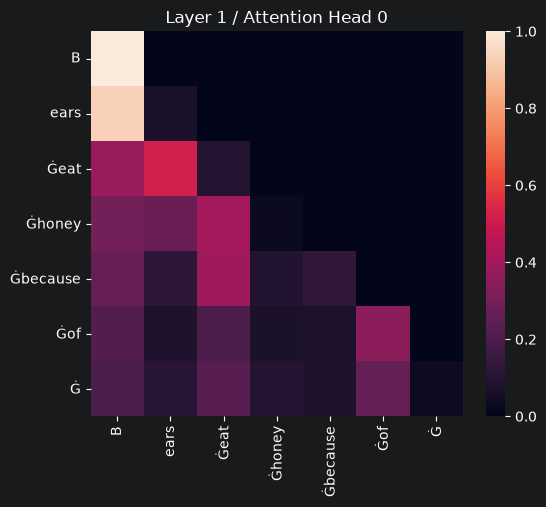

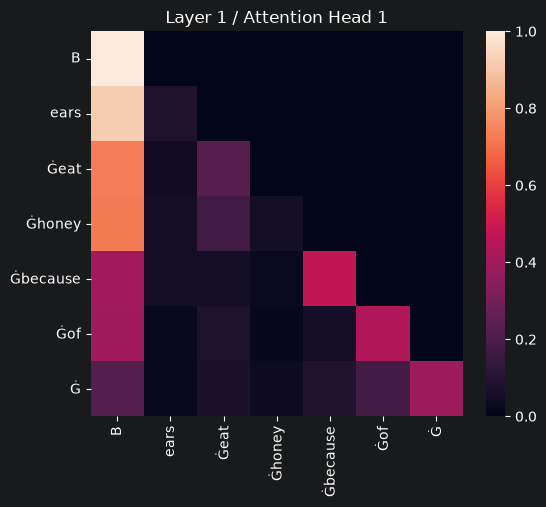

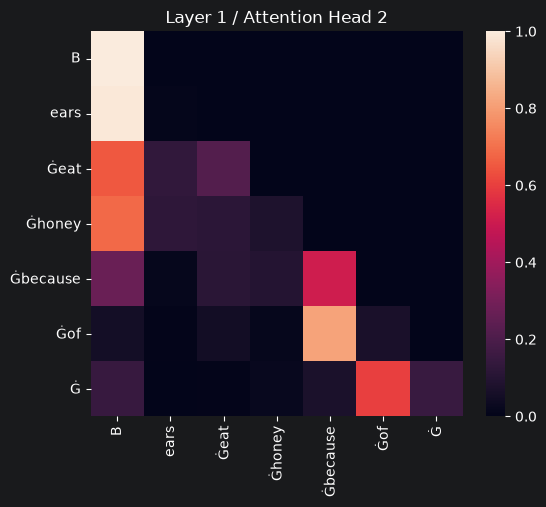

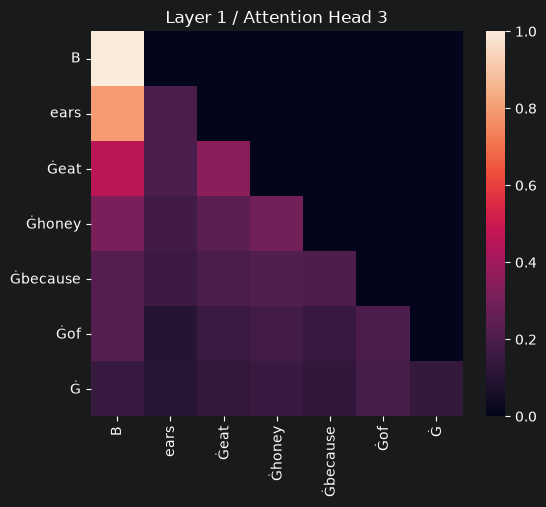

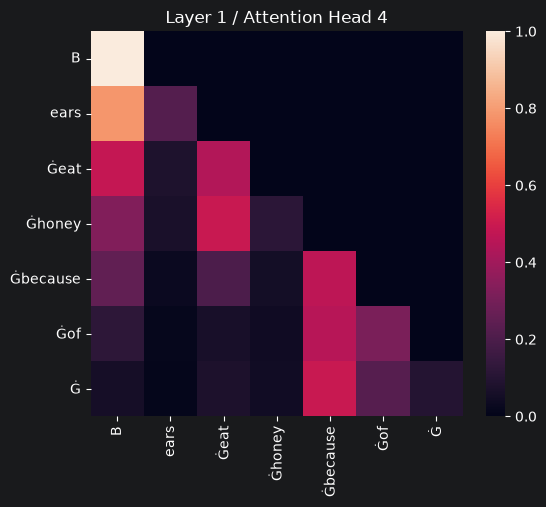

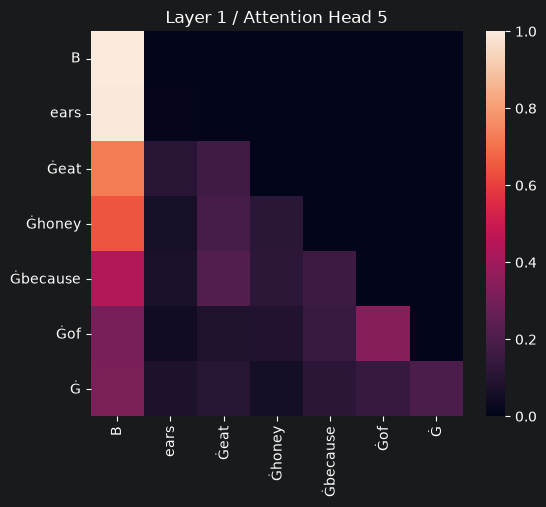

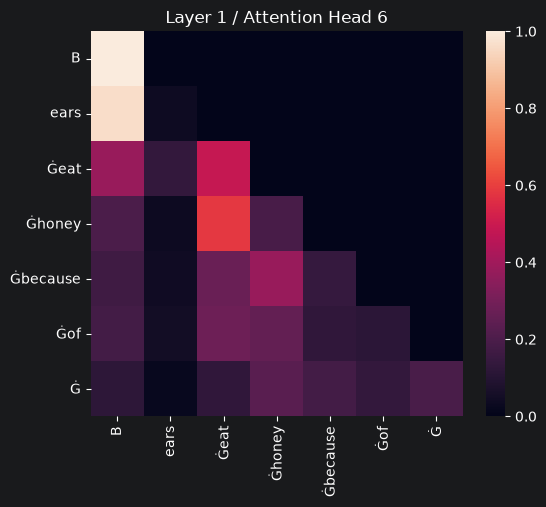

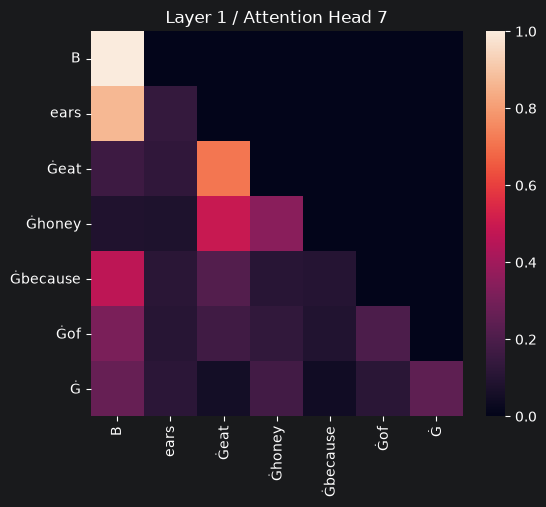

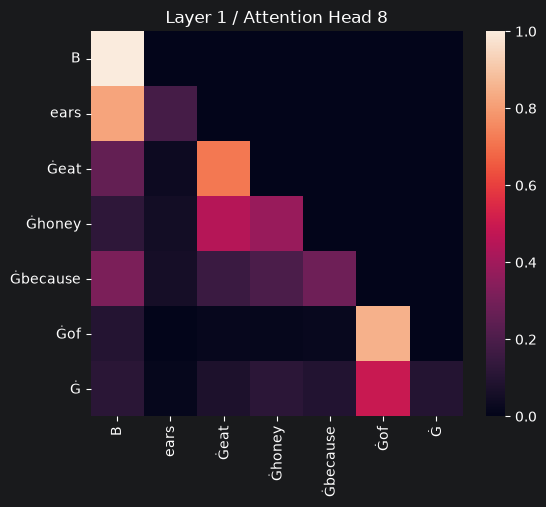

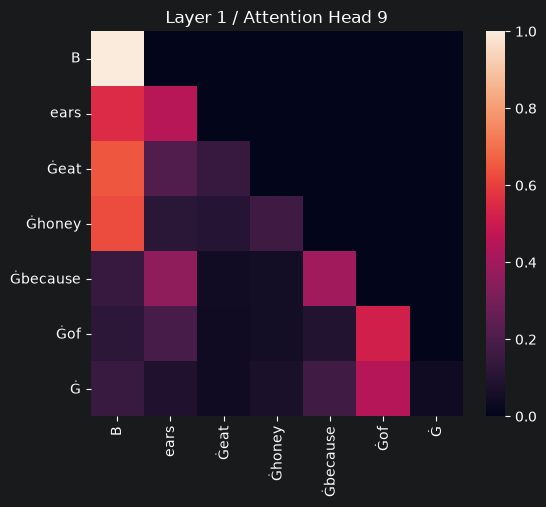

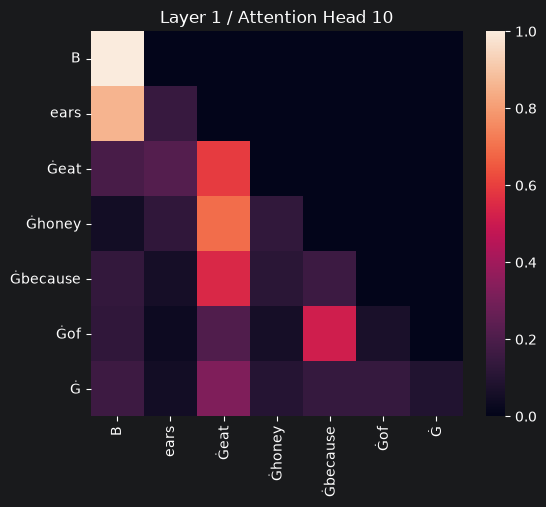

Эталонные outputs не сохранены (start(..., with_reference=False)).
Эталонные outputs не сохранены (start(..., with_reference=False)).


In [29]:
# Точечно включаем только heatmap внимания и смотрим на блок 1
walker.set_enabled("attention_heatmap", True)
state_attn_only = walker.start(prompt, with_reference=False)
walker.skip_to(state_attn_only, 1, stage="resid2", detail=True)
walker.set_enabled("attention_heatmap", False)

### Сохранение тензоров на диск — тоже рекордер (`TensorSaver`)

Указываете, на каких стадиях и какие ключи `state.cache` сохранять — он пишет каждый тензор отдельным файлом `<prompt>__L<layer>__<stage>__<key>.<fmt>` в заданную папку. Включается/выключается так же, как и визуальные рекордеры.

In [30]:
saver = TensorSaver(enabled=True, stages={"resid2"}, cache_keys=["resid2"],
                     out_dir=SAMPLES_DIR + sample_label, fmt="pt")
walker.add_recorder(saver)

save_state = walker.start(prompt, with_reference=False)
walker.skip_to(save_state, 0, stage="resid2", detail=False)

walker.remove_recorder("tensor_saver")  # выключаем, чтобы не мешал дальнейшим прогонам
import os
print("Сохранено:", os.listdir(SAMPLES_DIR + sample_label))

Эталонные outputs не сохранены (start(..., with_reference=False)).
Эталонные outputs не сохранены (start(..., with_reference=False)).
Сохранено: ['Bears_eat_honey_because_of___L0__resid2__resid2.pt']


## 4) Батч-обработка: N промптов, выгрузка выбранных тензоров в файл

`run_batch` прогоняет `walker` на списке промптов, для каждого доезжает до `(capture_layer, capture_stage)` и забирает из `state.cache` тензоры по `capture_keys`. Всё складывается в один файл через `save_path`.

Пример ниже — то, что было в пункте 4 ТЗ: 10 промптов, attention 3-го слоя.

In [31]:
batch_walker = GPT2Walker(model, tokenizer)  # чистый walker без визуальных рекордеров -- для скорости

CAPTURE_LAYER = min(3, len(model.transformer.h) - 1)

batch_results = run_batch(
    batch_walker,
    sentences,                       # 10 промптов из списка выше; возьмите math_expressions для другого набора
    capture_layer=CAPTURE_LAYER,
    capture_stage="softmax",         # хотим веса внимания -- они появляются на стадии softmax
    capture_keys=["attn_weights"],
    save_path=SAMPLES_DIR + f"L{CAPTURE_LAYER}_attention_batch.pt",
    detail=True,                     # 'softmax' -- стадия внутри блока, нужен детальный путь
    with_reference=False,            # эталонный прогон не нужен -- так быстрее
)

print("\nПромпты в результате:", list(batch_results.keys()))

[1/10] 'Cats love fish because of '
[2/10] 'Dogs chase balls because of '
[3/10] 'Birds build nests because of '
[4/10] 'Bears eat honey because of '
[5/10] 'Cows chew grass because of '
[6/10] 'Frogs catch flies because of '
[7/10] 'Bees make honey because of '
[8/10] 'Monkeys love bananas because of '
[9/10] 'Spiders spin webs because of '
[10/10] 'Horses eat hay because of '

Сохранено в ./samples/L3_attention_batch.pt

Промпты в результате: ['Cats love fish because of ', 'Dogs chase balls because of ', 'Birds build nests because of ', 'Bears eat honey because of ', 'Cows chew grass because of ', 'Frogs catch flies because of ', 'Bees make honey because of ', 'Monkeys love bananas because of ', 'Spiders spin webs because of ', 'Horses eat hay because of ']


In [32]:
# Загружаем сохранённое обратно и смотрим на форму/значения для одного промпта
loaded = torch.load(SAMPLES_DIR + f"L{CAPTURE_LAYER}_attention_batch.pt", weights_only=False)
example_prompt = sentences[0]
attn_example = loaded[example_prompt]["attn_weights"]
print(f"Промпт: {example_prompt!r}")
print("Форма attention:", attn_example.shape)  # [1, num_heads, seq, seq]

Промпт: 'Cats love fish because of '
Форма attention: torch.Size([1, 11, 7, 7])


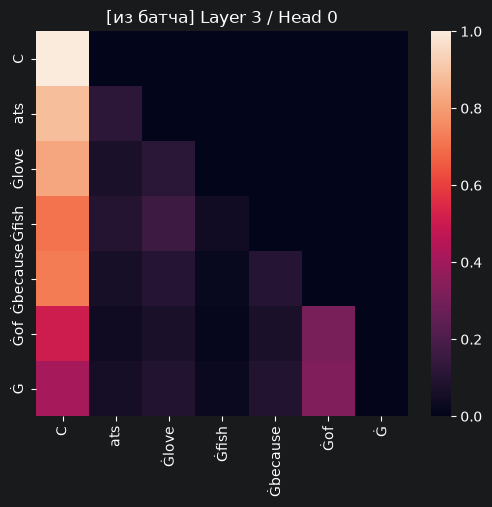

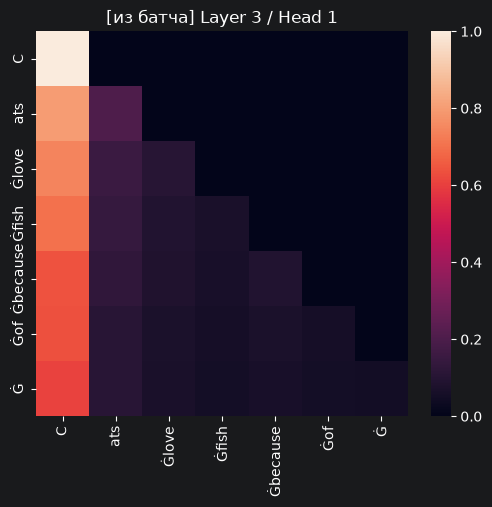

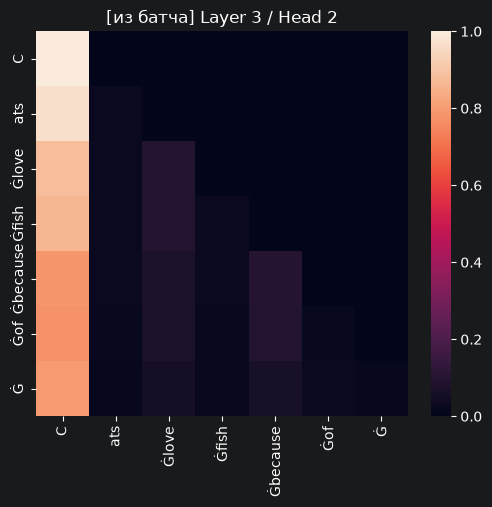

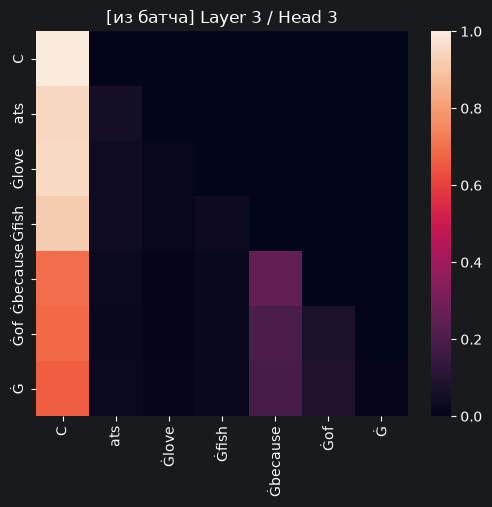

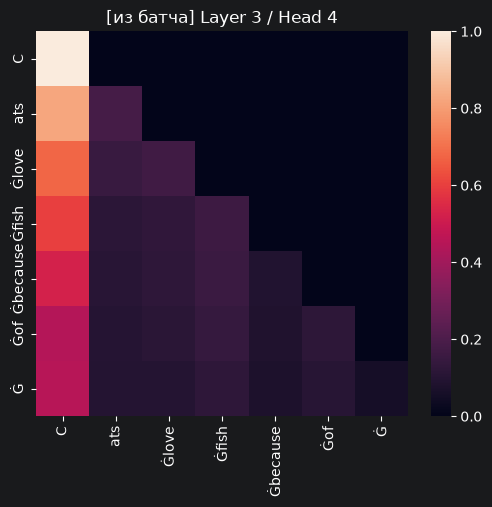

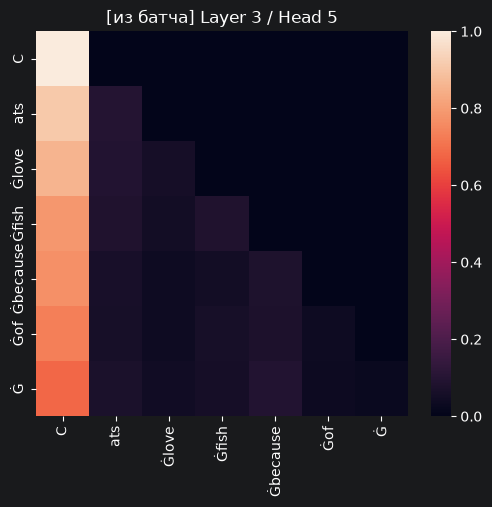

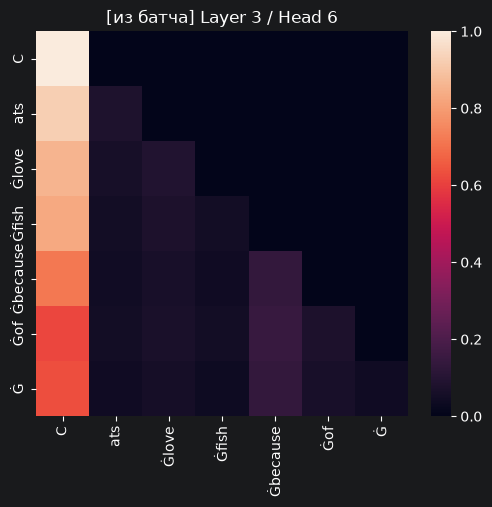

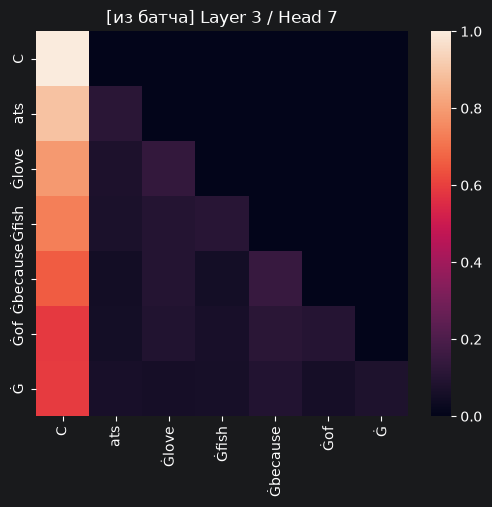

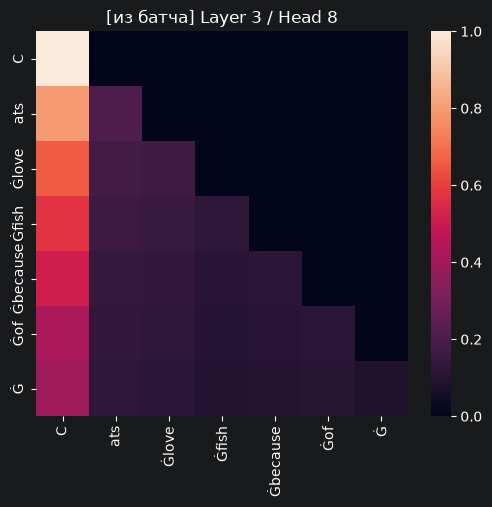

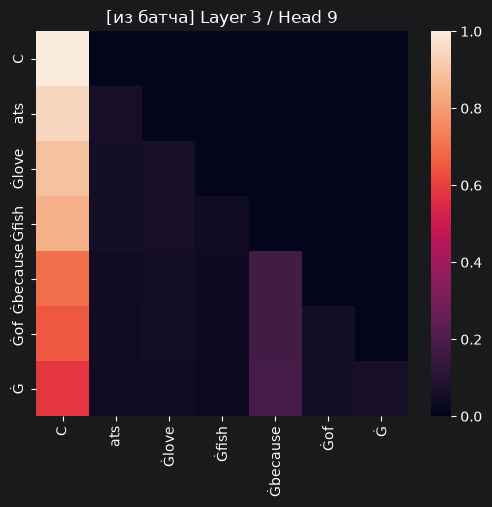

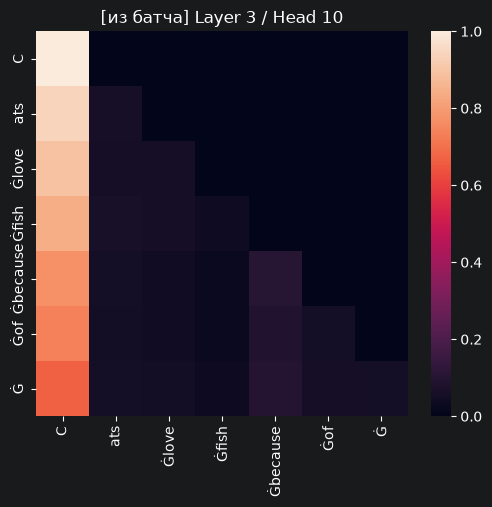

In [42]:
# Heatmap для загруженного из файла батч-результата (та же логика, что у AttentionHeatmapRecorder,
# применённая вручную к уже сохранённым данным)
import matplotlib.pyplot as plt
import seaborn as sns

example_tokens = tokenizer.tokenize(example_prompt)
heads = attn_example[0].to(torch.float32).numpy()
for i, head_matrix in enumerate(heads):
    plt.figure(figsize=(6, 5))
    plt.title(f"[из батча] Layer {CAPTURE_LAYER} / Head {i}")
    sns.heatmap(head_matrix, xticklabels=example_tokens, yticklabels=example_tokens)
    plt.show()

### Батч другого типа: финальные предсказания по всем промптам

То же `run_batch`, но останавливаемся на последнем блоке и забираем `resid2` (вход в `ln_f`) — а дальше для каждого промпта вручную считаем `ln_f + lm_head` и печатаем топ-1 предсказание. Так можно собрать любую сводную статистику по батчу, не открывая каждый прогон по отдельности.

In [34]:
last_layer = len(model.transformer.h) - 1
final_batch = run_batch(
    batch_walker,
    sentences,
    capture_layer=last_layer,
    capture_stage="resid2",
    capture_keys=["resid2"],
    save_path=None,           # тут просто хотим результат в памяти, без файла
    detail=False,
    with_reference=False,
)

print()
for p, data in final_batch.items():
    with torch.no_grad():
        final_norm = model.transformer.ln_f(data["resid2"])
        logits = model.lm_head(final_norm)
    top_id = logits[0, -1].argmax().item()
    top_tok = tokenizer.convert_ids_to_tokens([top_id])[0]
    print(f"{p!r:45s} -> {top_tok!r}")

[1/10] 'Cats love fish because of '
[2/10] 'Dogs chase balls because of '
[3/10] 'Birds build nests because of '
[4/10] 'Bears eat honey because of '
[5/10] 'Cows chew grass because of '
[6/10] 'Frogs catch flies because of '
[7/10] 'Bees make honey because of '
[8/10] 'Monkeys love bananas because of '
[9/10] 'Spiders spin webs because of '
[10/10] 'Horses eat hay because of '

'Cats love fish because of '                  -> 'icky'
'Dogs chase balls because of '                -> 'icky'
'Birds build nests because of '               -> 'vern'
'Bears eat honey because of '                 -> 'ery'
'Cows chew grass because of '                 -> 'ile'
'Frogs catch flies because of '               -> 'ile'
'Bees make honey because of '                 -> 'iced'
'Monkeys love bananas because of '            -> 'icky'
'Spiders spin webs because of '               -> 'ich'
'Horses eat hay because of '                  -> 'ile'
